# student performance analysis 


### installing required  libraries and performing basic opertaion to get the over view

In [80]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


In [81]:
df= pd.read_csv('StudentsPerformance.csv')
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.columns)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtyp

### plotting histogram for trends  

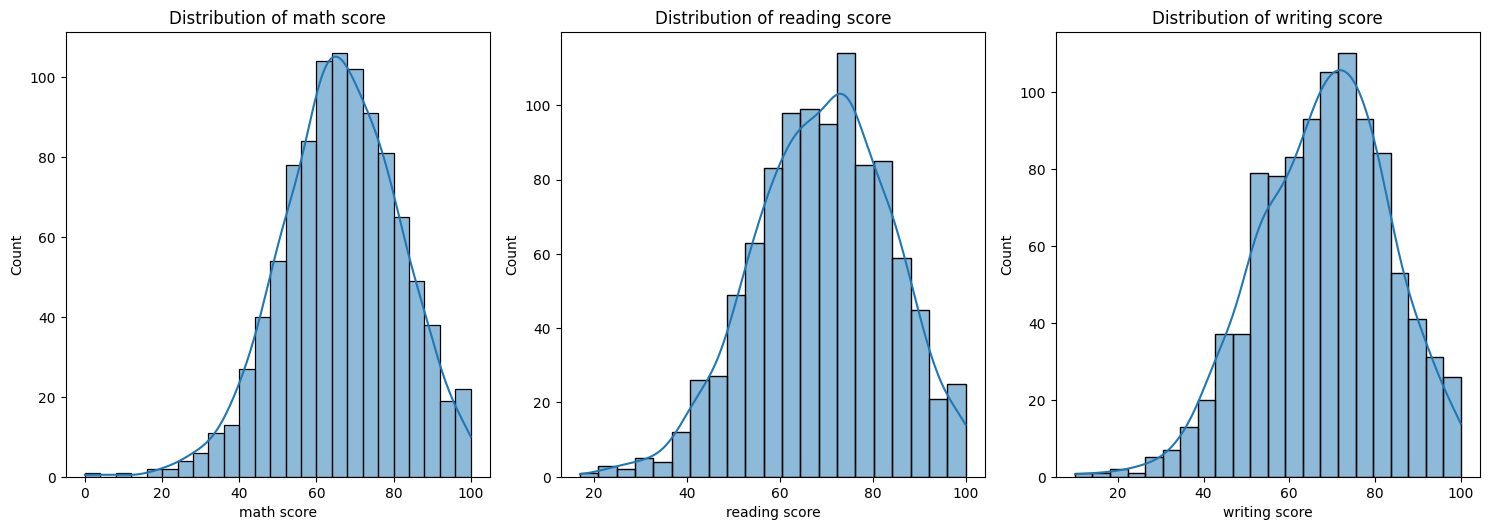

In [82]:
#this is so that only numeric features get selected as we can only plot histgorams for numeric features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
# plotting histograms for all numeric features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

##### here all of the marks features are slightly left screwed so overall peformance can be considered great


### pie chart of gender relative to marks

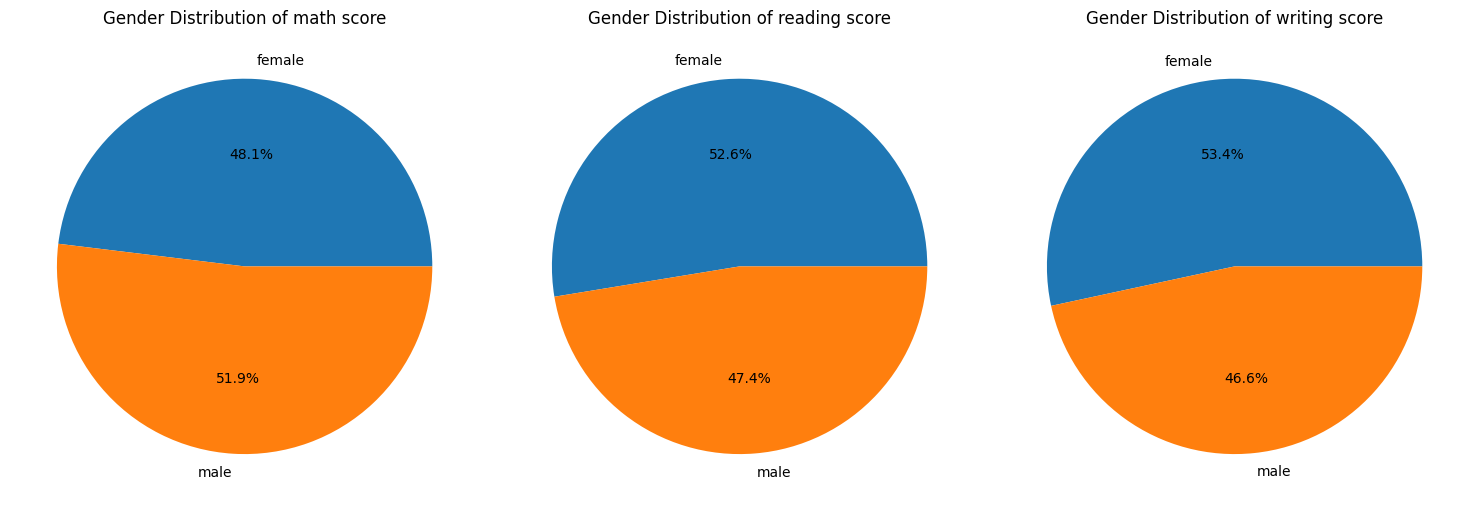

In [83]:
plt.figure(figsize=(15, 5))
for i, score in enumerate(['math score', 'reading score', 'writing score']):
    plt.subplot(1, 3, i+1)
    gender_mean = df.groupby('gender')[score].mean()
    plt.pie(gender_mean, labels=gender_mean.index, autopct='%1.1f%%')
    plt.title(f'Gender Distribution of {score}')
plt.tight_layout()
plt.show()

##### here female have performed better in reading and writing while male have performed better in maths


### relation of categorical features with average marks 

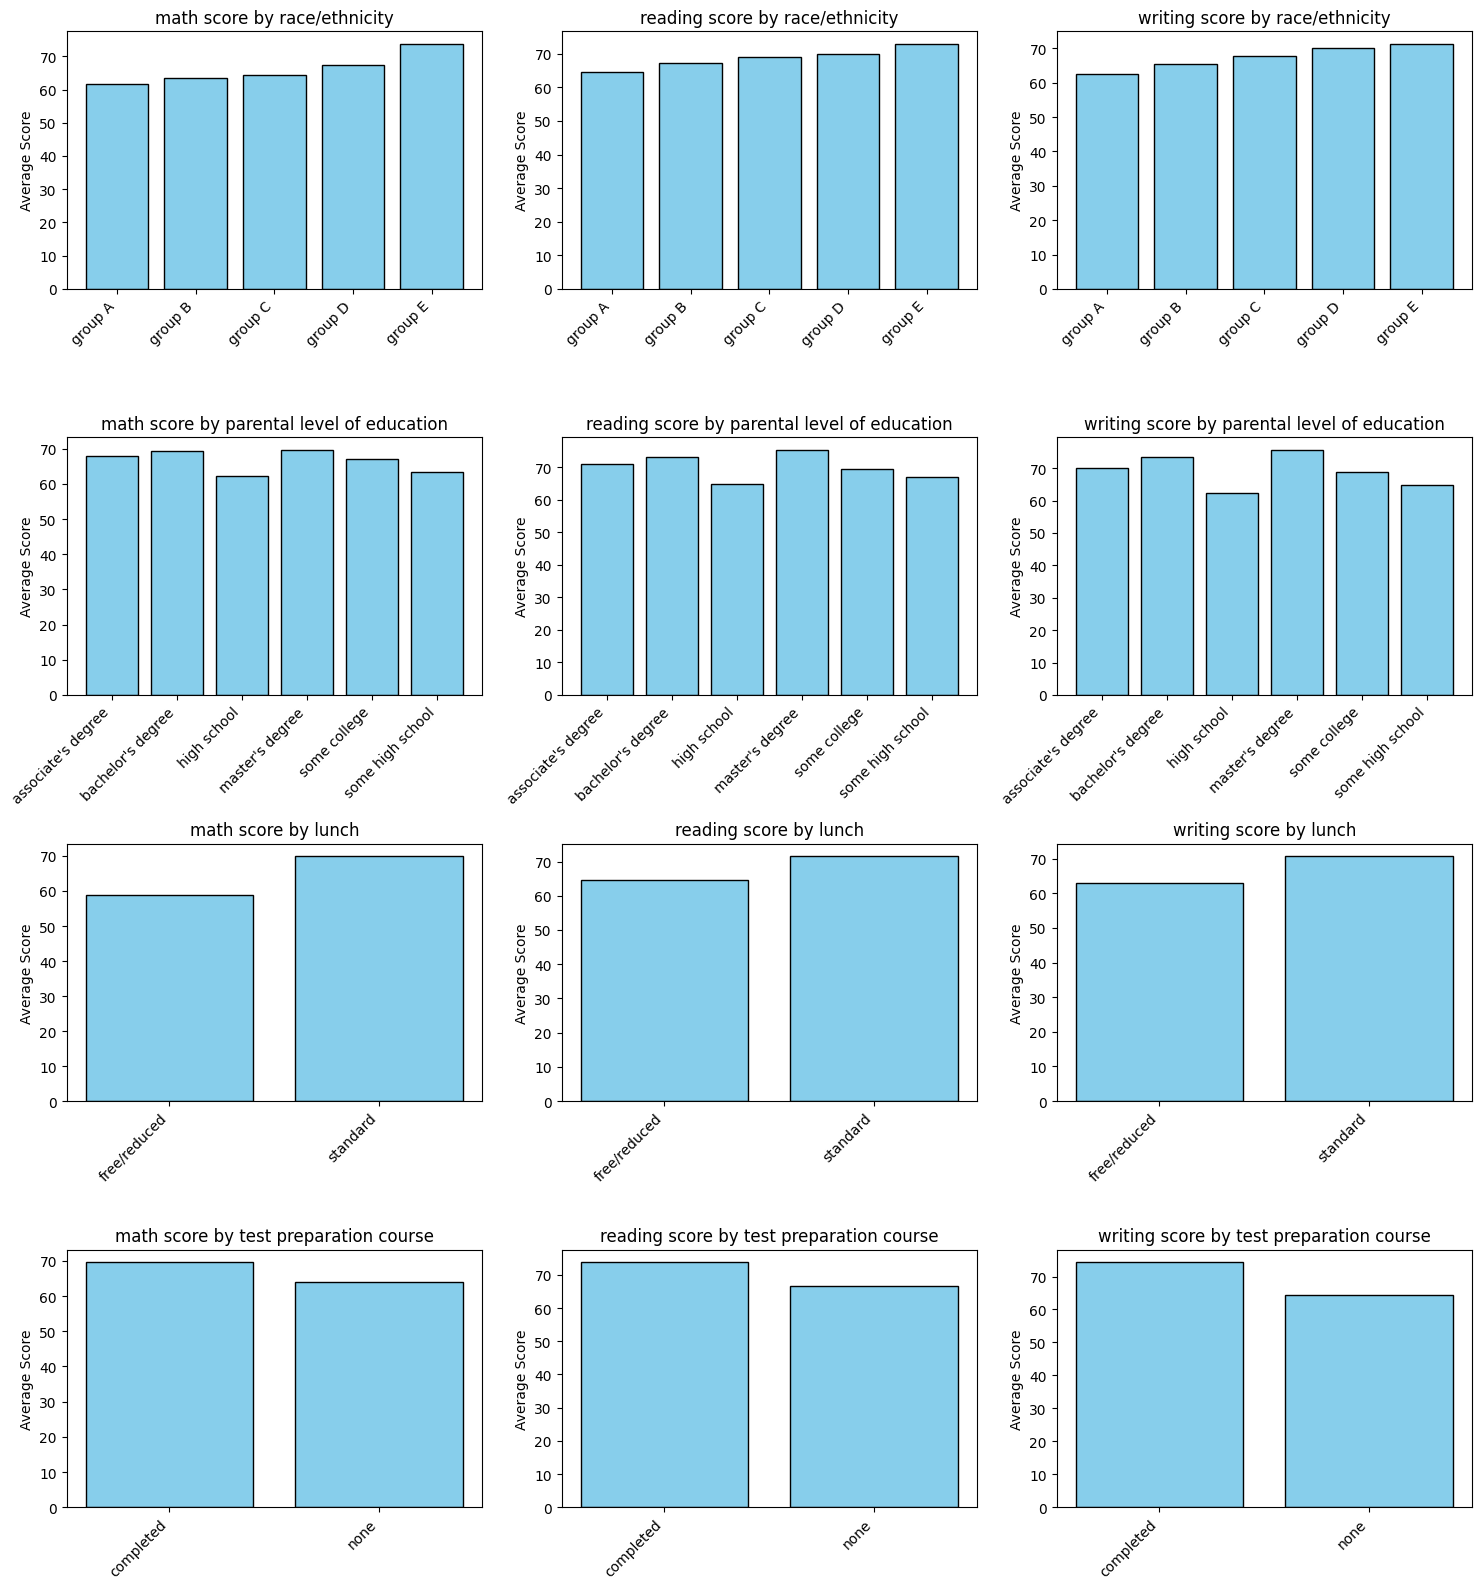

In [84]:
categorical_features = ['race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

plt.figure(figsize=(15, 16))
for i, feature in enumerate(categorical_features):
    for j, score_type in enumerate(['math score', 'reading score', 'writing score']):
        plt.subplot(4, 3, i*3 + j + 1)
        means = df.groupby(feature)[score_type].mean()
        plt.bar(means.index, means.values, color='skyblue', edgecolor='black')
        plt.xticks(rotation=45, ha='right')
        plt.title(f'{score_type} by {feature}')
        plt.ylabel('Average Score')
plt.tight_layout()
plt.show()


##### in first row group A have lowest average score while group E performs better in each subject.
##### here high school student perform slightly worst then others while bachelor's and master's perform slightly better than other overall no big difference in performance.
##### having standard lunch can also affect student score.
##### here the students who have complicated course have clearly out performed in terms of scoring the marks
 

### using heatmap for corrilation between marks of different subjects


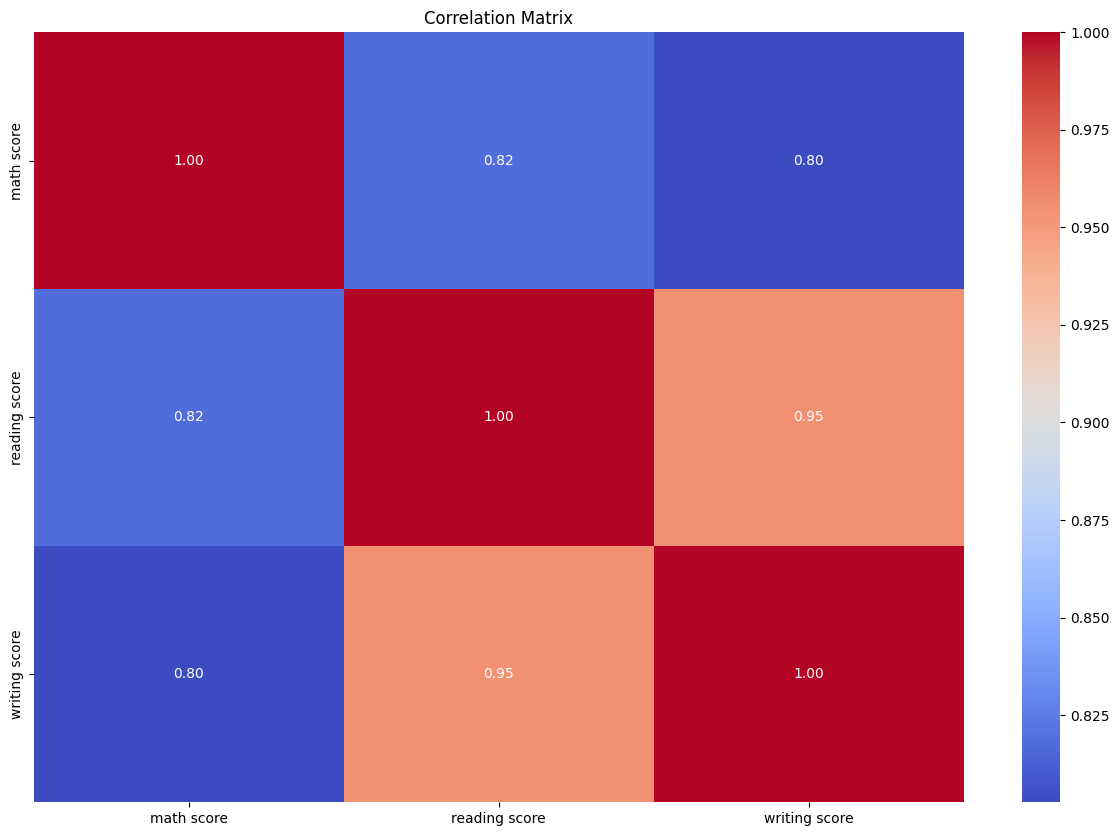

In [85]:
cm = df[numerical_features].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

##### though there is a high correlation between features reading and writing have higher correlation it make sense as both compliment each other

### creating new features for more EDA

In [86]:

df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df['performance_category'] = pd.cut(df['average_score'], 
                                  bins=[0, 40, 60, 80, 100], 
                                  labels=['Needs Improvement', 'Average', 'Good', 'Excellent'])
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance_category
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Good
1,female,group C,some college,standard,completed,69,90,88,82.333333,Excellent
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Average
4,male,group C,some college,standard,none,76,78,75,76.333333,Good
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000,Excellent
996,male,group C,high school,free/reduced,none,62,55,55,57.333333,Average
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000,Good
998,female,group D,some college,standard,completed,68,78,77,74.333333,Good


### pie chart for performance_category 


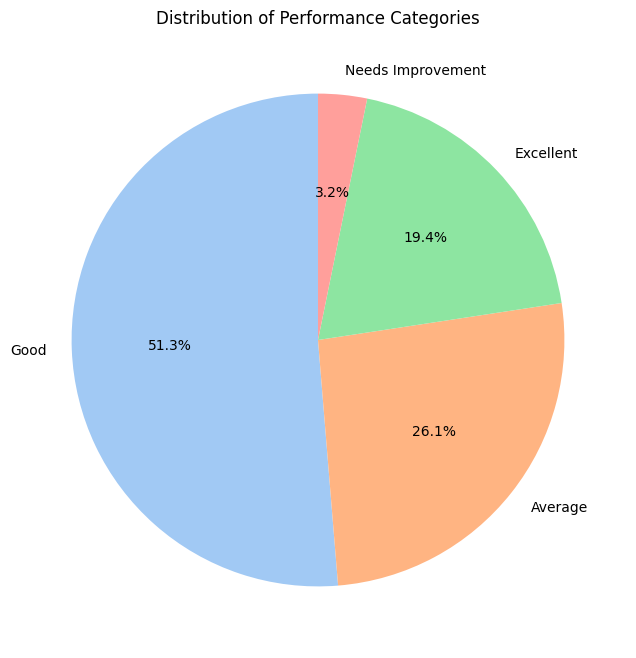

In [87]:
# Pie chart for performance_category
performance_counts = df['performance_category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(performance_counts, labels=performance_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Performance Categories')
plt.show()

##### most of students have performed good while only few students need improvement 

### barplot of average marks

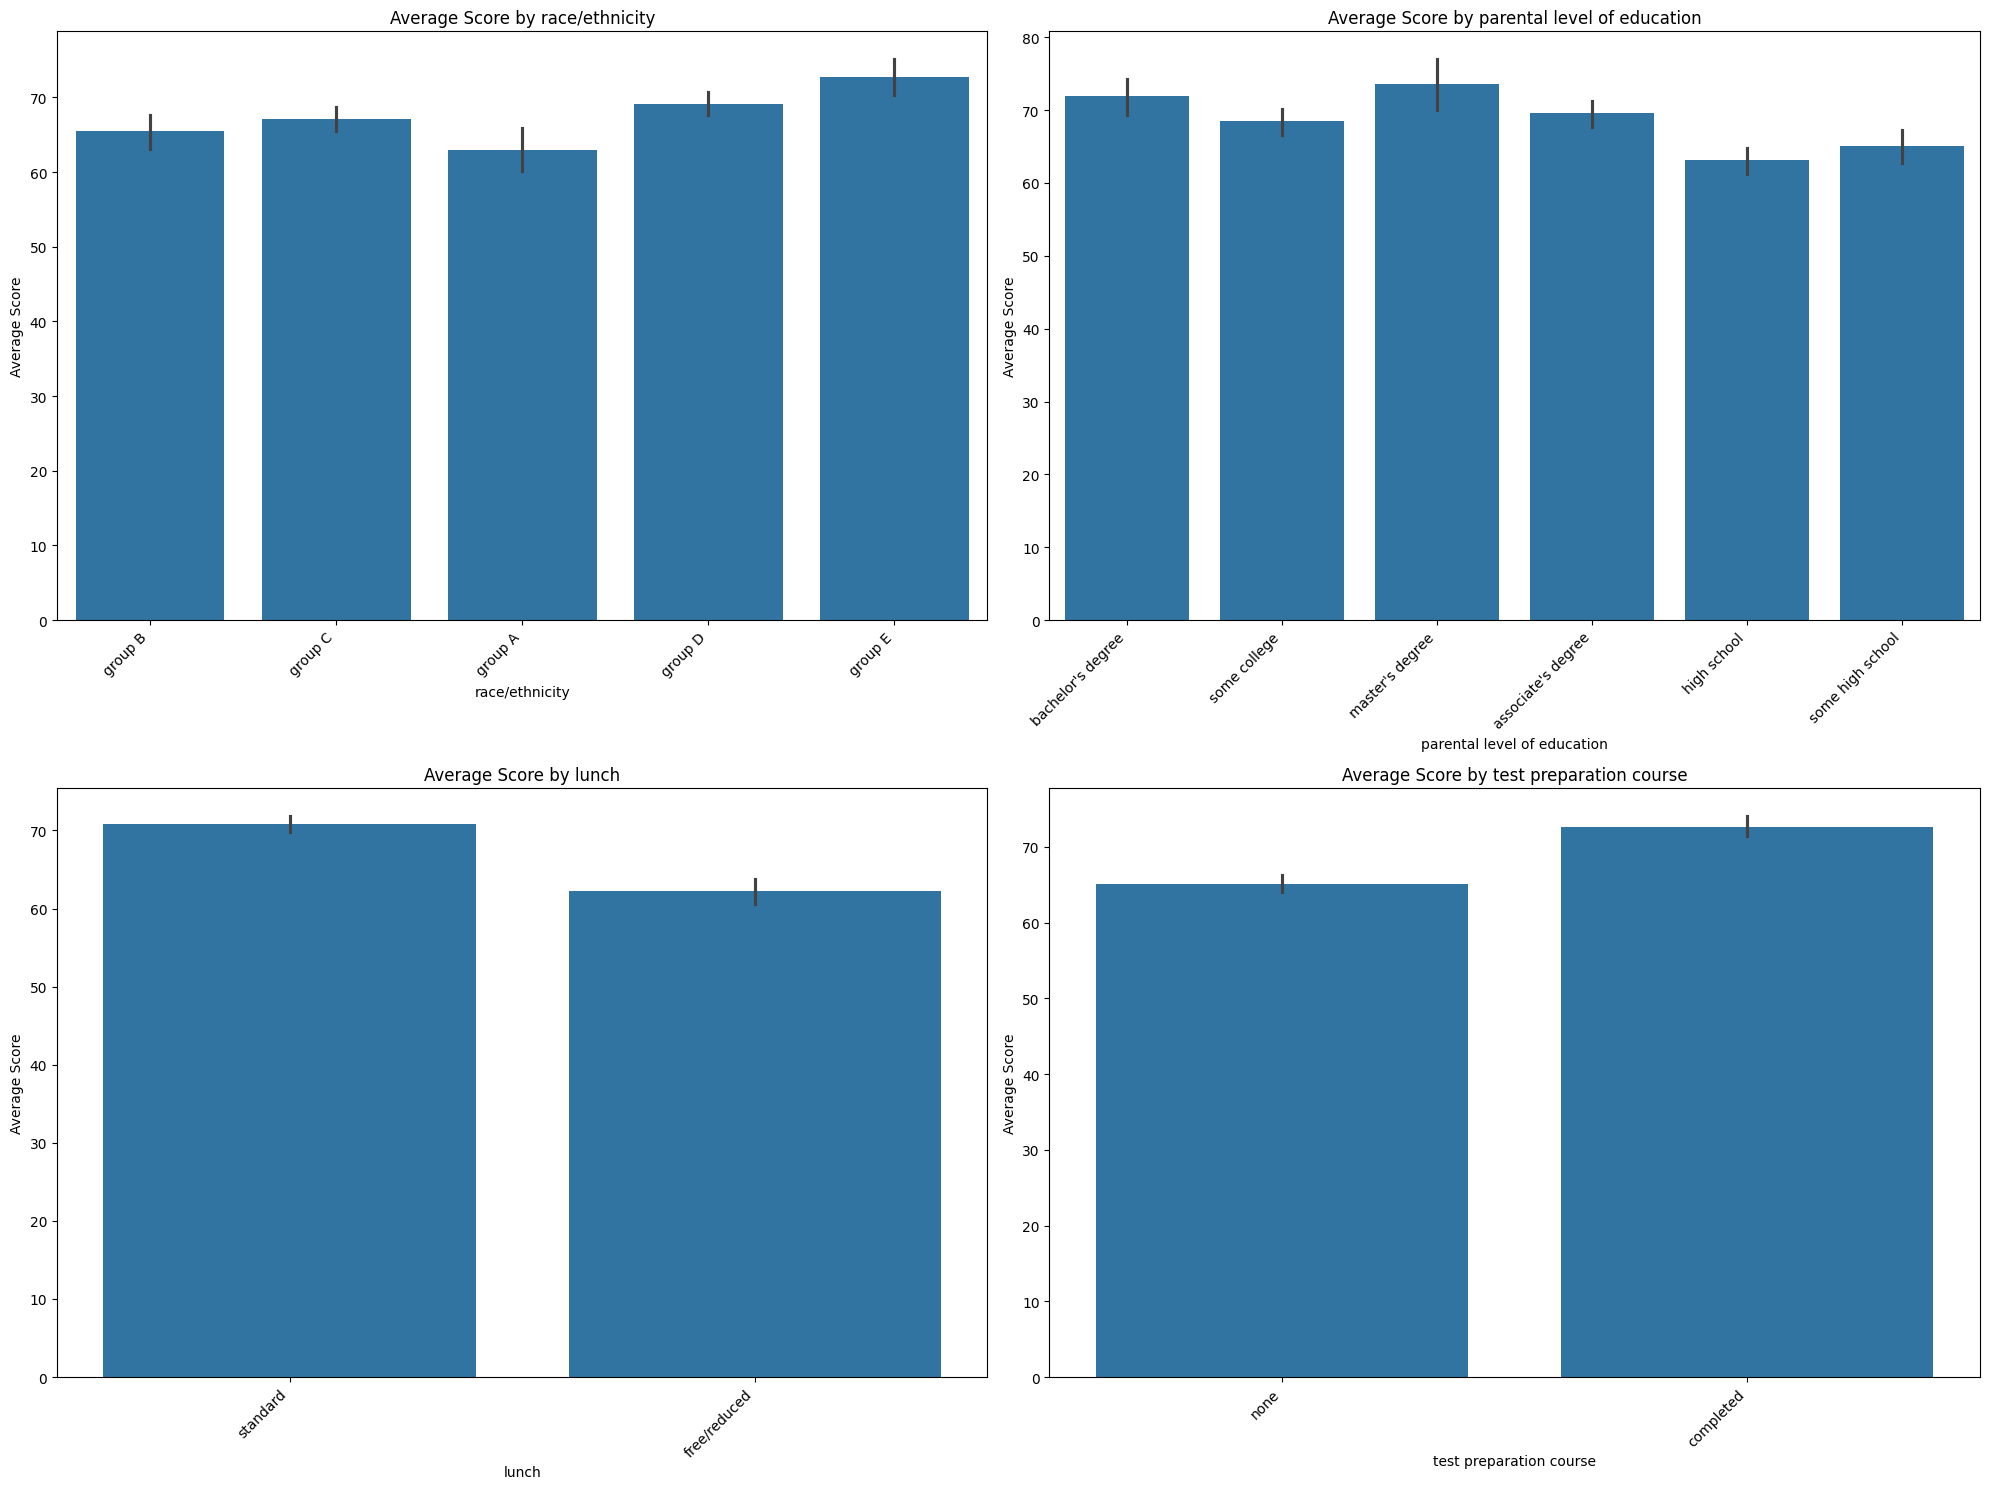

In [88]:
plt.figure(figsize=(20, 15))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    sns.barplot(data=df, x=feature, y='average_score', edgecolor=None)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Average Score by {feature}')
    plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

##### these are just the bar plots of categorical features with the average marks of all subjects combined 

### T-Tests for Gender Comparison

In [89]:
from scipy import stats

# T-test for math scores by gender
male_math = df[df['gender'] == 'male']['math score']
female_math = df[df['gender'] == 'female']['math score']

t_stat, p_value = stats.ttest_ind(male_math, female_math)
print(f"Math scores t-test: t={t_stat:.4f}, p={p_value:.4f}")
print(f"Male math mean: {male_math.mean():.2f}, Female math mean: {female_math.mean():.2f}")

# Repeat for reading and writing scores
for subject in ['reading score', 'writing score']:
    male_scores = df[df['gender'] == 'male'][subject]
    female_scores = df[df['gender'] == 'female'][subject]
    
    t_stat, p_value = stats.ttest_ind(male_scores, female_scores)
    print(f"{subject} t-test: t={t_stat:.4f}, p={p_value:.4f}")
    print(f"Male {subject} mean: {male_scores.mean():.2f}, Female {subject} mean: {female_scores.mean():.2f}")



Math scores t-test: t=5.3832, p=0.0000
Male math mean: 68.73, Female math mean: 63.63
reading score t-test: t=-7.9593, p=0.0000
Male reading score mean: 65.47, Female reading score mean: 72.61
writing score t-test: t=-9.9796, p=0.0000
Male writing score mean: 63.31, Female writing score mean: 72.47


Gender Differences (T-Test Results)

Math Scores: t=5.3832, p=0.0000

Males scored significantly higher in math (68.73 vs 63.63)
The t-value is positive and large, indicating a substantial difference
The p-value of 0.0000 (which means p<0.001) shows this difference is highly statistically significant
Interpretation: "Male students scored approximately 5 points higher in math than female students, a highly significant difference (p<0.001)"


Reading Scores: t=-7.9593, p=0.0000

Females scored significantly higher in reading (72.61 vs 65.47)
The negative t-value indicates females scored higher
The p-value of 0.0000 shows this is highly significant
Interpretation: "Female students scored approximately 7 points higher in reading than male students, a highly significant difference (p<0.001)"


Writing Scores: t=-9.9796, p=0.0000

Females scored significantly higher in writing (72.47 vs 63.31)
This is the largest gender gap (over 9 points)
The extremely large t-value (-9.9796) indicates a very strong effect
Interpretation: "Female students outperformed male students in writing by more than 9 points, showing the largest and most significant gender gap among all subjects (p<0.001)"

### ANOVA for Multi-Group Comparisons

In [90]:
# ANOVA for math scores by race/ethnicity
groups = []
for group in df['race/ethnicity'].unique():
    groups.append(df[df['race/ethnicity'] == group]['math score'])

f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA for math scores by race/ethnicity: F={f_stat:.4f}, p={p_value:.4f}")

# Show means by group
print(df.groupby('race/ethnicity')['math score'].mean())

# Function to run ANOVA across multiple categories and subjects
def run_anova(dataframe, category, subjects):
    print(f"\n--- ANOVA Results for {category} ---")
    
    for subject in subjects:
        groups = []
        for group in dataframe[category].unique():
            groups.append(dataframe[dataframe[category] == group][subject])
        
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"\n{subject} by {category}: F={f_stat:.4f}, p={p_value:.4f}")
        
        # Show means for each group
        means = dataframe.groupby(category)[subject].mean().sort_values(ascending=False)
        print("Group means:")
        for group, mean in means.items():
            print(f"  {group}: {mean:.2f}")


# Run ANOVA for multiple categories
categories = ['race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
subjects = ['math score', 'reading score', 'writing score']

for category in categories:
    run_anova(df, category, subjects)

ANOVA for math scores by race/ethnicity: F=14.5939, p=0.0000
race/ethnicity
group A    61.629213
group B    63.452632
group C    64.463950
group D    67.362595
group E    73.821429
Name: math score, dtype: float64

--- ANOVA Results for race/ethnicity ---

math score by race/ethnicity: F=14.5939, p=0.0000
Group means:
  group E: 73.82
  group D: 67.36
  group C: 64.46
  group B: 63.45
  group A: 61.63

reading score by race/ethnicity: F=5.6217, p=0.0002
Group means:
  group E: 73.03
  group D: 70.03
  group C: 69.10
  group B: 67.35
  group A: 64.67

writing score by race/ethnicity: F=7.1624, p=0.0000
Group means:
  group E: 71.41
  group D: 70.15
  group C: 67.83
  group B: 65.60
  group A: 62.67

--- ANOVA Results for parental level of education ---

math score by parental level of education: F=6.5216, p=0.0000
Group means:
  master's degree: 69.75
  bachelor's degree: 69.39
  associate's degree: 67.88
  some college: 67.13
  some high school: 63.50
  high school: 62.14

reading scor

Most influential factors (ranked by average F-value):

Socioeconomic status (lunch program) - strongest effect
Test preparation course - second strongest
Parental education - third strongest
Race/ethnicity - still significant but relatively less impact


Subject-specific patterns:

Math shows the largest socioeconomic gap
Writing shows the strongest response to test preparation
Language skills (reading/writing) are more influenced by parental education than math


Educational implications:

Targeted interventions for lower socioeconomic status students could address the largest performance gaps
Test preparation seems especially valuable for improving writing scores
Students with less educated parents might benefit from additional language arts support

### boxplot for visualizing significance 

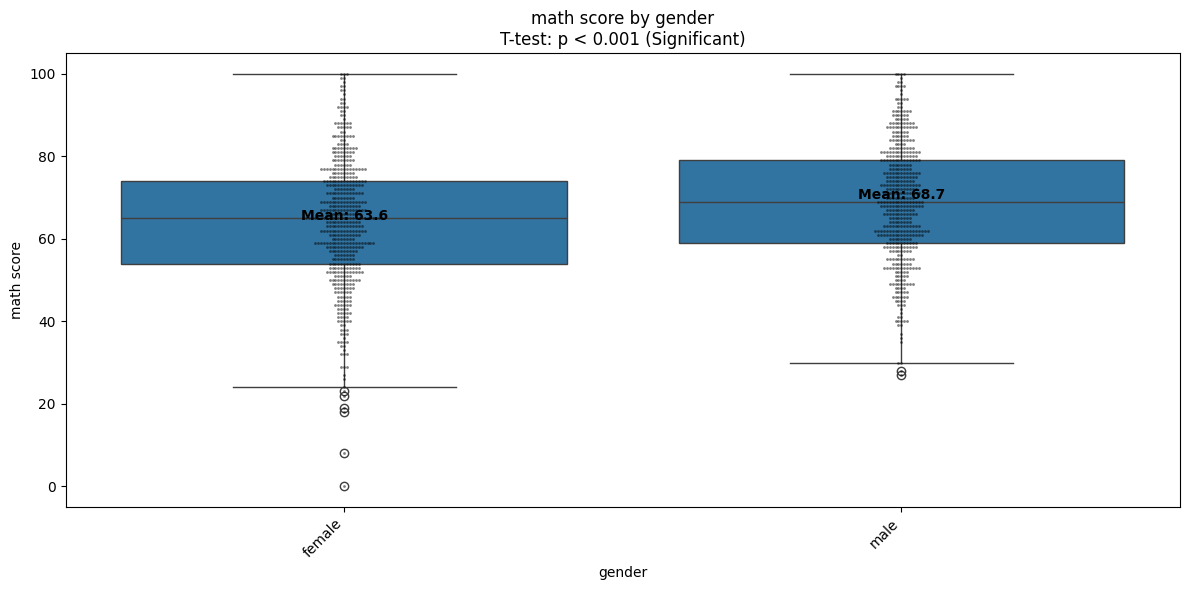

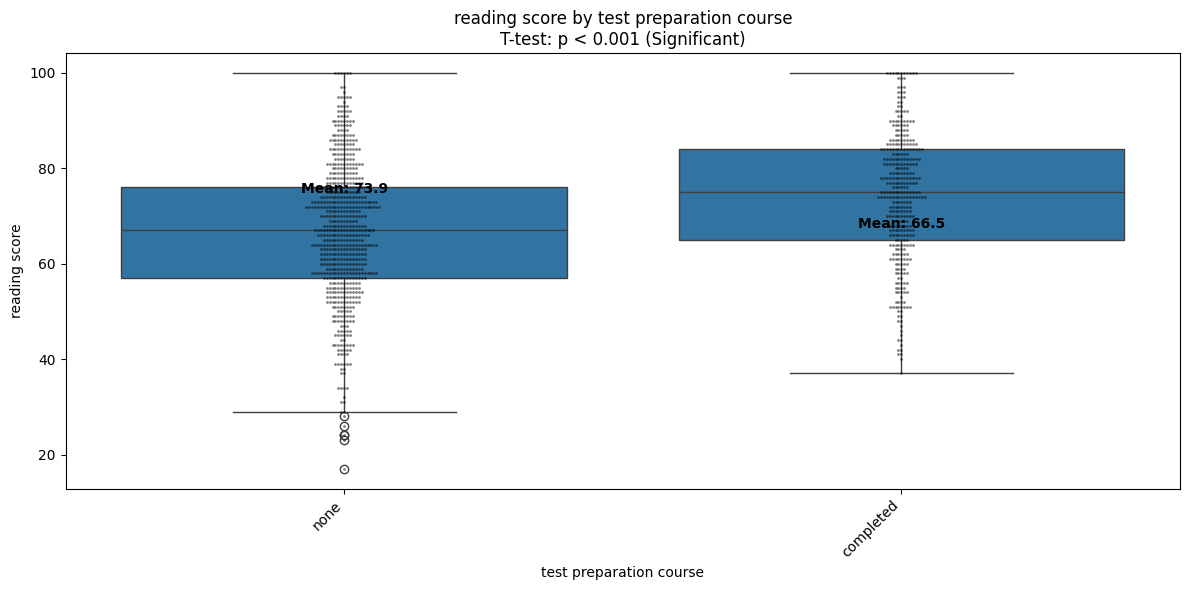

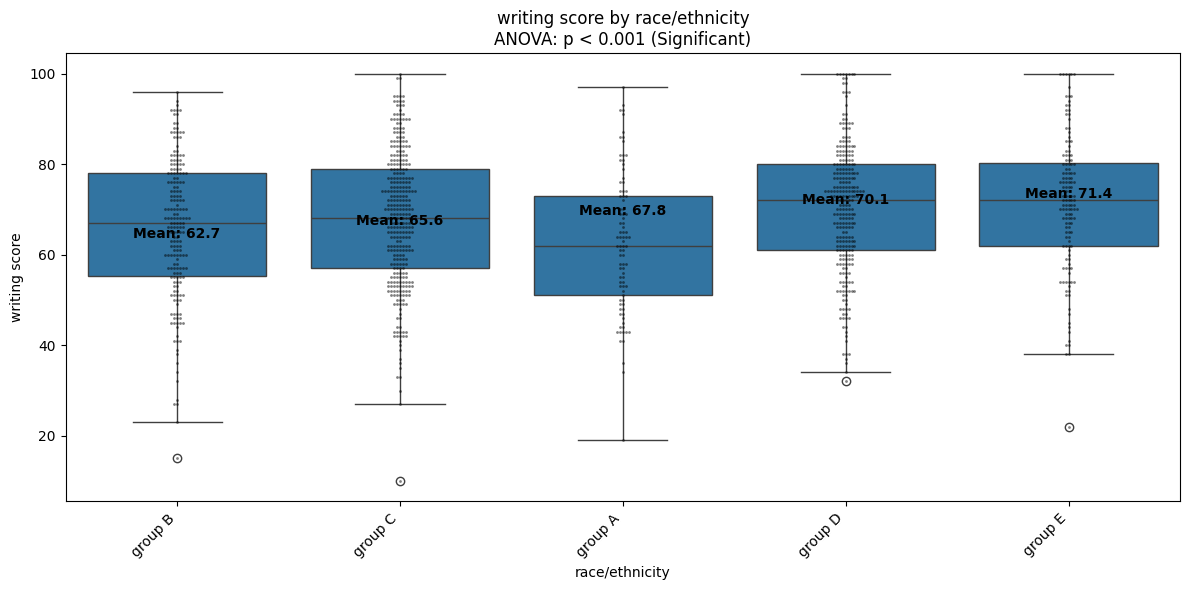

In [91]:
# Create a function to visualize t-test or ANOVA results
def plot_group_comparison(df, category, subject, title=None, sig_threshold=0.05):
    plt.figure(figsize=(12, 6))
    
    # Create the boxplot
    ax = sns.boxplot(x=category, y=subject, data=df)
    
    # Add swarmplot for individual data points
    sns.swarmplot(x=category, y=subject, data=df, color='black', alpha=0.5, size=2)
    
    # Run statistical test
    groups = df[category].unique()
    
    # If only 2 groups, use t-test
    if len(groups) == 2:
        group1 = df[df[category] == groups[0]][subject]
        group2 = df[df[category] == groups[1]][subject]
        stat, p_value = stats.ttest_ind(group1, group2)
        test_name = "T-test"
    # Otherwise use ANOVA
    else:
        anova_groups = []
        for group in groups:
            anova_groups.append(df[df[category] == group][subject])
        stat, p_value = stats.f_oneway(*anova_groups)
        test_name = "ANOVA"
    
    # Add statistical test results to plot
    plt.title(f"{title if title else f'{subject} by {category}'}\n"
              f"{test_name}: {'p < 0.001' if p_value < 0.001 else f'p = {p_value:.3f}'} "
              f"{'(Significant)' if p_value < sig_threshold else '(Not Significant)'}")
    
    # Add group means as text
    group_means = df.groupby(category)[subject].mean()
    for i, mean in enumerate(group_means):
        ax.text(i, mean+1, f"Mean: {mean:.1f}", ha='center', fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Example usage
plot_group_comparison(df, 'gender', 'math score')
plot_group_comparison(df, 'test preparation course', 'reading score')
plot_group_comparison(df, 'race/ethnicity', 'writing score')

### Post-Hoc Tukey Test Explanation

In [92]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Function to run post-hoc Tukey HSD test after significant ANOVA
def run_tukey_test(df, category, subject):
    # Prepare data
    data = df[[category, subject]].dropna()
    
    # Run Tukey test
    tukey = pairwise_tukeyhsd(data[subject], data[category], alpha=0.05)
    
    # Display results
    print(f"\nTukey HSD results for {subject} by {category}:")
    print(tukey)
    
    # Return results for further analysis if needed
    return tukey

# Example for education level and math scores
tukey_results = run_tukey_test(df, 'parental level of education', 'average_score')
tukey_results=run_tukey_test(df,"race/ethnicity","average_score")


Tukey HSD results for average_score by parental level of education:
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.3547 0.6743  -2.1739  6.8832  False
associate's degree       high school  -6.4721    0.0 -10.3682 -2.5761   True
associate's degree   master's degree   4.0298 0.3567  -1.7924   9.852  False
associate's degree      some college  -1.0927 0.9618  -4.8488  2.6635  False
associate's degree  some high school  -4.4611 0.0183  -8.4541  -0.468   True
 bachelor's degree       high school  -8.8268    0.0 -13.4584 -4.1952   True
 bachelor's degree   master's degree   1.6751 0.9748  -4.6629  8.0132  False
 bachelor's degree      some college  -3.4473 0.2479   -7.962  1.0673  False
 bachelor's degree  some high school  -6.8157 0.0006 -11.5293 -2.1022   True
       

##### this test tells us which group exactly differ from each other

### Conclusion: Student Performance Analysis
#### Summary of Findings
Our comprehensive statistical analysis of the student performance dataset has revealed several significant patterns and relationships that provide valuable insights into the factors influencing academic outcomes. Through t-tests and ANOVA analyses, we have identified how demographic factors, socioeconomic indicators, and educational interventions relate to student performance across math, reading, and writing assessments.
### Key Insights

#### Gender Differences:

Male students perform significantly better in mathematics (p<0.001)
Female students demonstrate superior performance in reading and writing (p<0.001)
The gender gap is most pronounced in writing scores (9.16 points difference)


#### Racial/Ethnic Disparities:

Significant performance differences exist across racial/ethnic groups in all subjects (p<0.001)
Group E consistently outperforms all other groups across all subjects
Group A consistently shows the lowest performance across all subjects
The gap between highest and lowest performing groups is most pronounced in mathematics (12.19 points)


#### Socioeconomic Impact:

Lunch program status (free/reduced vs. standard) shows the strongest effect among all analyzed factors
Students with standard lunch outperform those with free/reduced lunch by 11.11 points in math, 7.00 points in reading, and 7.80 points in writing
The extremely high F-values (up to 140.12) indicate socioeconomic status is the most powerful predictor of academic performance


#### Parental Education:

Higher parental education levels consistently correlate with better student performance
The impact increases progressively from math to reading to writing, suggesting language skills may be more influenced by home educational environment
Students whose parents hold master's degrees score 13.23 points higher in writing than those whose parents completed only high school


#### Test Preparation Impact:

Completing the test preparation course significantly improves performance across all subjects
The effect is most dramatic for writing scores (F=108.35, p<0.001)
The improvement ranges from 5.62 points in math to 9.92 points in writing